## 20.2-1
Show the d and π values that result from running breadth-first search on
the directed graph of Figure 20.2(a), using vertex 3 as the source.

This is figure 20.2, where a is the first representation of the graph, which actually could also look like the what could be the structure of an argument.

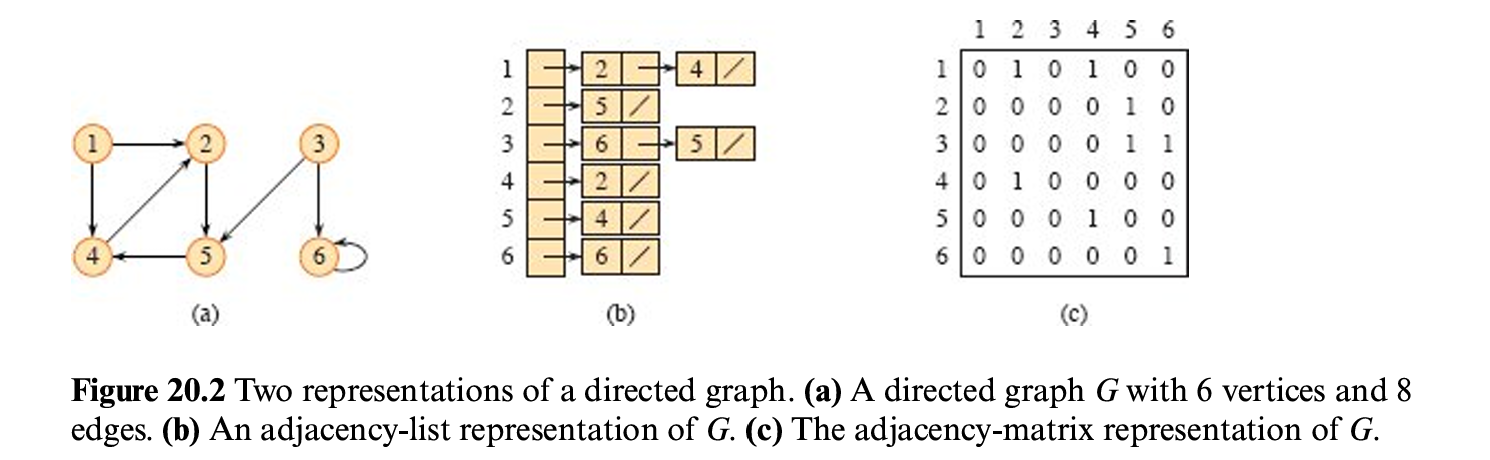

In [3]:
from collections import deque

def breadth_first_search(graph, start):
    visited = {key: False for key in graph}
    distance = {key: None for key in graph}
    queue = deque([start])
    distance[start] = 0
    while queue:
        vertex = queue.popleft()
        if not visited[vertex]:
            visited[vertex] = True

            for neighbor in graph[vertex]:
                if not visited[neighbor]:
                    distance[neighbor] = distance[vertex] + 1
                    queue.append(neighbor)

    return visited, distance


In [1]:
graph = {1: [2,4],
         2: [5],
         3: [5,6],
         4: [],
         5: [4],
         6: [6]}

In [4]:
breadth_first_search(graph, start=3)

({1: False, 2: False, 3: True, 4: True, 5: True, 6: True},
 {1: None, 2: None, 3: 0, 4: 2, 5: 1, 6: 1})

In [8]:
breadth_first_search(graph, 3)

({1: False, 2: False, 3: True, 4: True, 5: True, 6: True},
 {1: None, 2: None, 3: 0, 4: 2, 5: 1, 6: 1})

## 20.2-2

Show the d and π values that result from running breadth-first search on
the undirected graph of Figure 20.3, using vertex u as the source.
Assume that neighbors of a vertex are visited in alphabetical order.

In [9]:
graph = {'v': ['y','w', 's'],
         'w': ['v', 'y', 's', 't'],
         'r': ['s','w', 't'],
         't': ['u', 'r'],
         'u': ['t', 'y', 's'],
         'y': ['v', 'u'],
         's': ['u', 'v', 'r'],
         'x': ['z', 'w', 'y'],
         'z': ['x', 'w']
         }

In [10]:
breadth_first_search(graph, 'u')

({'v': True,
  'w': True,
  'r': True,
  't': True,
  'u': True,
  'y': True,
  's': True,
  'x': False,
  'z': False},
 {'v': 2,
  'w': 3,
  'r': 2,
  't': 1,
  'u': 0,
  'y': 1,
  's': 1,
  'x': None,
  'z': None})

## 20.2-3
Show that using a single bit to store each vertex color suffices by
arguing that the BFS procedure produces the same result if line 18 is
removed. Then show how to obviate the need for vertex colors
altogether.

In [16]:
def bfs(G, s):
      for u in G.V - {s}:
          u.d = float('inf')
          u.pi = None

      s.d = 0
      s.pi = None
      Q = deque([s])

      while Q:
          u = Q.popleft()
          for v in G.adj[u]:
              if v.d == float('inf'):   # replaces color check
                  v.d = u.d + 1
                  v.pi = u
                  Q.append(v)

No color attribute needed at all — d == ∞ means undiscovered, d < ∞ means
  discovered. The d attribute does double duty: it both guards against
  re-enqueuing and stores the shortest-path distance.

## 20.2-4
What is the running time of BFS if we represent its input graph by an
adjacency matrix and modify the algorithm to handle this form of
input

With the matrix representation we have a V x V 2D array which means that the storage goes up from $O(|V|+|E|)$ to $O(|V|^2)$. When it comes to time complexity the graph is slower as it has to scan all the potential neighbors of $V$ whereas the adjacency list only scans the actual neighbors. That means time complexity also increases from $O(V+E)$ to $O(V^2)$

## 20.2-5
Argue that in a breadth-first search, the value u.d assigned to a vertex u
is independent of the order in which the vertices appear in each
adjacency list. Using Figure 20.3 as an example, show that the breadth
first tree computed by BFS can depend on the ordering within
adjacency lists

The distance is independent of the way the order in which the vertices appear in an adjacency list because the distance is dependent on the graph structure and from which vertex/node we begin the exploration.

## 20.2-6

Give an example of a directed graph G = (V, E), a source vertex s
∈ V, and a set of tree edges E π ⊆ E such that for each vertex v ∈ V, the
unique simple path in the graph (V, Eπ) from s to v is a shortest path in
G, yet the set of edges Eπ cannot be produced by running BFS on G, no
matter how the vertices are ordered in each adjacency list.

## 20.2-7

There are two types of professional wrestlers: “faces” (short for
“babyfaces,” i.e., “good guys”) and “heels” (“bad guys”). Between any
pair of professional wrestlers, there may or may not be a rivalry. You are
given the names of $n$ professional wrestlers and a list of $r$ pairs of
wrestlers for which there are rivalries. Give an $O(n + r)$-time algorithm
that determines whether it is possible to designate some of the wrestlers
as faces and the remainder as heels such that each rivalry is between a
face and a heel. If it is possible to perform such a designation, your
algorithm should produce it.

In [12]:
names = ["John", "Peter", "Bo", "Cal"]
rivalries = {name: [] for name in names}  # initialize all

# then add edges both directions
rivalries["John"].append("Peter")
rivalries["Peter"].append("John")
rivalries["John"].append("Bo")
rivalries["Bo"].append("John")
rivalries["Bo"].append("Cal")
rivalries["Cal"].append("Bo")


In [13]:
rivalries

{'John': ['Peter', 'Bo'],
 'Peter': ['John'],
 'Bo': ['John', 'Cal'],
 'Cal': ['Bo']}

In [14]:
def assign_wrestlers(names, rivalries):
    designation = {}
    for start in names:
        if start in designation:
            continue
        designation[start] = 'face'
        queue = deque([start])

        while queue:
            u = queue.popleft()
            for v in rivalries.get(u, []):
                if v not in designation:
                    designation[v] = 'heel' if designation[u] == 'face' else 'face'
                    queue.append(v)
                elif designation[v] == designation[u]:
                    return None
    return designation

In [15]:
assign_wrestlers(names=names, rivalries=rivalries)

{'John': 'face', 'Peter': 'heel', 'Bo': 'heel', 'Cal': 'face'}

The BFS starts at John → labels Peter and Bo as heels → from Bo labels Cal as face. Clean designation, no conflicts.